# Machine Learning : Linear Regression and Logistic Regression Exercises

## Part1 : Linear regression
In this part, you will implement linear regression with multiple variables to predict the Sales. 

Utilize all available advertising budget fields (TV, Radio, and Newspaper) to develop a multivariate regression model predicting Sales. This step aims at exploring how different types of advertisement investments collectively affect sales figures.

Suppose you are a data analyst for a company looking to optimize its advertising strategy to maximize sales. The dataset ``data1.csv`` you'll be working with includes information from various advertising channels and their impact on product sales.


This dataset comprises five columns:

- *TV Ad Budget* (numeric - FLOAT): 
   - Represents the budget allocated for TV advertisements.
- *Radio Ad Budget* (numeric - FLOAT): 
   - Reflects the budget spent on radio advertisements.
- *Newspaper Ad Budget* (numeric - FLOAT): 
   - Indicates the budget used for newspaper advertisements.
- *Sales* (numeric - FLOAT): 
   - The sales revenue generated, which is our target field to predict.
- *ID* (numeric - INT): 
   - An identifier for each record in the dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
path =  './data1.csv'
data = pd.read_csv(path)
data.columns = ['ID', 'TV', 'Radio', 'Newspaper', 'Sales']
data.head()

,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


Plotting the data
Before starting on any task, it is often useful to understand the data by visualizing it. For this dataset, you can use a scatter plot to visualize the data with two properties to plot.

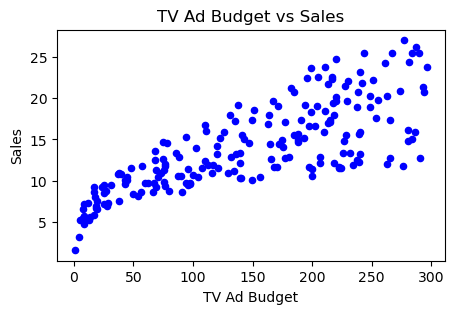

In [4]:
fig, ax = plt.subplots(1,figsize=(5, 3))

data.plot(kind='scatter', x='TV', y='Sales', color='b', ax=ax)

# selectable：add title and axle title
ax.set_title('TV Ad Budget vs Sales')
ax.set_xlabel('TV Ad Budget')
ax.set_ylabel('Sales')

# show the graph
plt.show()

### Feature Normalization 

By looking at the dataset values, note that ``TV`` sizes are about 10 times the number of ``Sales``. When features differ by orders of magnitude, first performing feature scaling can make gradient descent converge much more quickly.

Firstly, to define a ``featureNormalize`` function to perform Z-Score normalization on the training data.

##### <span style="color:red"> Your Implementation Below ⬇︎</span>

In [6]:
def featureNormalize(X):
    # your code here
    # mean and std
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Z-Score standardization
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

Gradient Descent
In this part, you will fit the linear regression parameters 
 to our dataset using gradient descent. The objective of linear regression is to minimize the cost function

$$J\left( \theta  \right)=\frac{1}{2m}\sum\limits_{i=1}^{m}{{{\left( {{h}_{\theta }}\left( {{x}^{(i)}} \right)-{{y}^{(i)}} \right)}^{2}}}$$
where the hypothesis $h_{\theta}(x)$ is given by the linear model.
Recall that the parameters of your model are the $\theta_{j}$ values. These are the values you will adjust to minimize cost $J\left( \theta  \right)$. One way to do this is to
use the batch gradient descent algorithm. In batch gradient descent, each
iteration performs the update

#### 1). Computing the cost $J(\theta)$
- $\theta$ initialized to zeros 
- Implement the ``computeCost()`` function.  

##### <span style="color:red"> Your Implementation Below ⬇︎</span>

In [10]:
def computeCost(X, y, theta):
    # your code here
    m = len(y)
    h = X.dot(theta)
    cost = np.sum(np.power(h - y, 2)) / (2 * m)
    return cost

Insert a new column with ones for the intercept term in linear regression:

In [12]:
data.insert(0, 'Ones', 1)

Data initialization: 
set X (training data - 'TV'，'Radio', 'Newspaper') and y (target variable - 'Sales')

Use Feature Normalization:
Standardize X/Y features except inserted 'Ones'

##### <span style="color:red"> Your Implementation Below ⬇︎</span>

In [15]:
X = data[['TV', 'Radio', 'Newspaper']].values  # 原始特征（无偏置列）
y = data[['Sales']].values

# Use Feature Normalization
X_norm, mu, sigma = featureNormalize(X)
X = X_norm

# add bias column
data_with_bias = pd.DataFrame(X, columns=['TV', 'Radio', 'Newspaper'])
data_with_bias.insert(0, 'Ones', 1)
X = data_with_bias.values

In [17]:
# Initialize theta
theta = np.zeros((4, 1))

X.shape, theta.shape, y.shape

((200, 4), (4, 1), (200, 1))

In [18]:
computeCost(X, y, theta)

111.858125

#### 2). Batch gradient decent
- ${{\theta }_{j}}:={{\theta }_{j}}-\alpha \frac{\partial }{\partial {{\theta }_{j}}}J\left( \theta  \right)$
- Initial setting:
 - $\alpha=0.01$
 - iteration:1500
- Implement the ``gradientDescent()`` function. After implementation, run the gradient descent algorithm to get the paramters
- Make sure to store the cost for each iteration in order to visualize the relationship between the cost and iterations

##### <span style="color:red"> Your Implementation Below ⬇︎</span>

In [20]:
def gradientDescent(X, y, theta, alpha, num_iters):
    # your code here
    m = len(y)
    cost = np.zeros(num_iters)
    for i in range(num_iters):
        # Calculate the predicted value
        h = X.dot(theta)
        # Update parameters
        theta = theta - (alpha / m) * X.T.dot(h - y)
        # Cost
        cost[i] = computeCost(X, y, theta)
    
    return theta, cost

In [21]:
alpha = 0.01
iters = 1500

In [22]:
theta, cost = gradientDescent(X, y, theta, alpha, iters)
theta

array([[14.02249602],
       [ 3.91925198],
       [ 2.79197782],
       [-0.02245325]])

##### <span style="color:red"> Your Plotting Below ⬇︎</span>
#### 3). Plotting the data and model

<span style="color:red"> Replace and plotting ⬇︎</span>

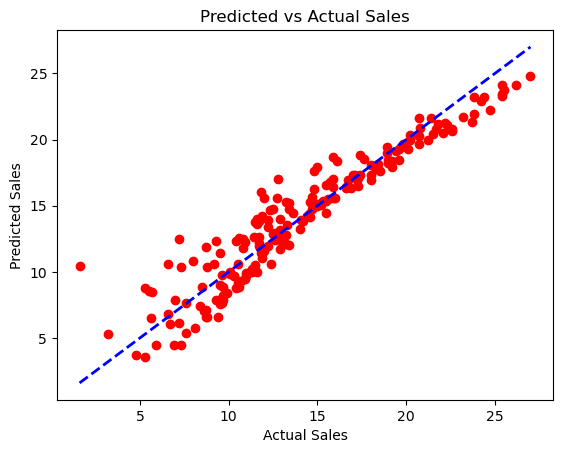

In [24]:
# your code here
# Predicted value vs. actual value
y_pred = X.dot(theta)
plt.scatter(y, y_pred, c='r')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'b--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales')
plt.show()

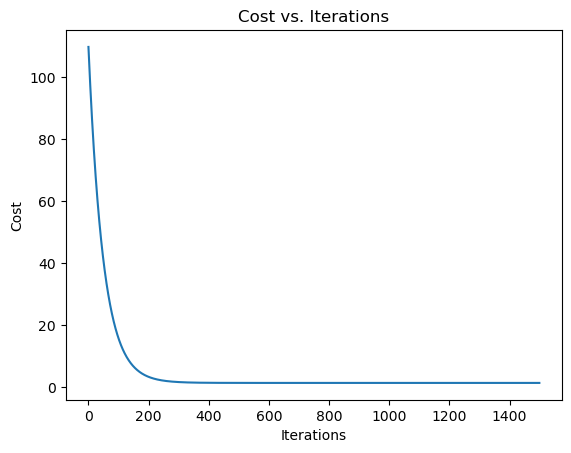

In [25]:
# your code here
# Cost function vs number of iterations
plt.plot(np.arange(iters), cost)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations')
plt.show()

## Part2 :1. Logistic Regression 
You will build a logistic regression model to predict whether a student gets admitted into a university. Suppose that you are the administrator of a university department and you want to determine each applicant’s chance of admission based on their results on two exams. You have historical data from previous applicants that you can use as a training set for logistic regression. For each training example, you have the applicant’s scores on two exams and the admissions decision. Your task is to build a classiﬁcation model that estimates an applicant’s probability of admission based the scores from those two exams.

### 1.1 Visualizing the data
Before starting to implement any learning algorithm, it is always good to visualize the data if possible.

First, let's import necessary libraries.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Second, let's read the data in from the data file.

In [43]:
#complete the code below
path = 'ex2data1.txt'
data = pd.read_csv(path, names=['Exam1', 'Exam2', 'Admitted']).copy()# fill your code here
data.head()

,Exam1,Exam2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


You will now complete the code in below so that it displays a scatter ﬁgure with X and Y axis to be the scores of the students, use color of each point to indicate whether a student is admitted or not.
##### <span style="color:red"> Your Implementation Below ⬇︎</span>

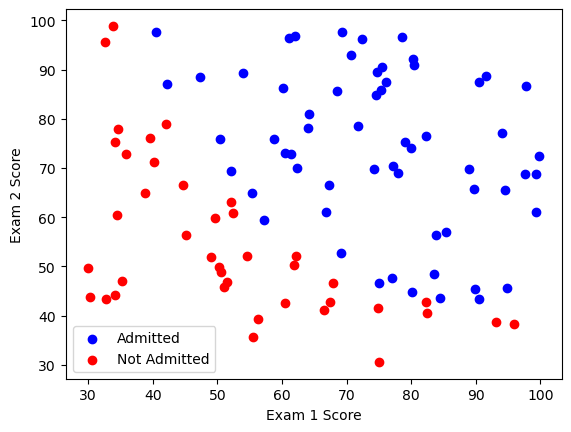

In [46]:
#complete the code below
# code here to plot a scatter figure to visualize the data as follows
positive = data[data['Admitted'] == 1]
negative = data[data['Admitted'] == 0]

plt.scatter(positive['Exam1'], positive['Exam2'], c='b', label='Admitted')
plt.scatter(negative['Exam1'], negative['Exam2'], c='r', label='Not Admitted')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend()

plt.show()

Looks like there is a clear boundary between two classes, so let's try to implement a logistic regression classifier to do the job。

### 1.2 Implementation of logistic regression
### 1.2.1 sigmoid 函数
Before you start with the actual cost function, recall that the sigmoid function and the logistic regression hypothesis
Please implement the sigmoid function in below<span style="color:red"> Your Implementation Below ⬇︎</span>

In [50]:
#complete the code below
#code here to implement the sigmoid function
def sigmoid(z):
    
    return 1 / (1 + np.exp(-z))
    

Plot the function below to verify if it is correct: <span style="color:red"> Your Implementation Below ⬇︎</span>

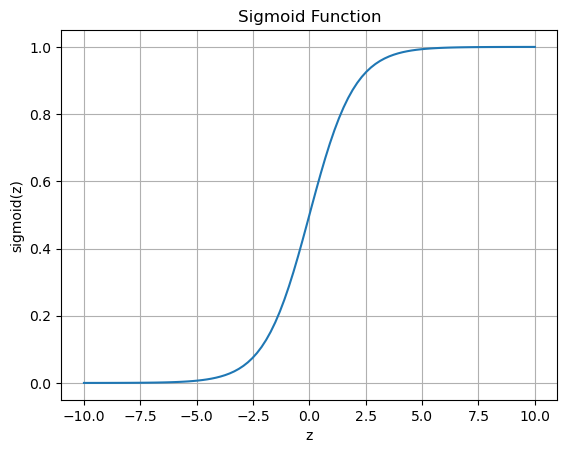

In [53]:
#complete the code below
#code here to plot the sigmoid function
z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function')
plt.grid(True)

plt.show()

### 1.2.2 Cost function and gradient
Now you will implement the cost function and gradient for logistic regression.：
##### <span style="color:red"> Your Implementation Below ⬇︎</span>

In [58]:
#complete the code below
#code here to implement the above cost function
def cost(theta, X, y):
    ''' cost function for you to minimize'''
    m = len(y)
    theta = theta.reshape(-1, 1)
    h = sigmoid(X.dot(theta))
    epsilon = 1e-10
    cost_val = (-1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost_val

Data initialization, Similar to what you did in linear regress exercise:
##### <span style="color:red"> Your Implementation Below ⬇︎</span>

In [60]:
#complete the code below
# add a ones column - this makes the matrix multiplication work out easier
data.insert(0, 'Ones', 1)

# set X (training data) and y (target variable)

X = data[['Ones', 'Exam1', 'Exam2']].values
y = data['Admitted'].values.reshape(-1, 1)

#initialize theta with zeros.
theta = np.zeros((3, 1))

Check if the dimensions of data are correct

In [63]:
theta

array([[0.],
       [0.],
       [0.]])

In [65]:
X.shape, theta.shape, y.shape

((100, 3), (3, 1), (100, 1))

Calculate the initial cost function value:

In [68]:
cost(theta, X, y)

0.6931471803599452

### gradient descent(梯度下降)
* we are going to use batch gradient descent）  
* implement the gradient function of each parameter using vector calculations： $\frac{1}{m} X^T( Sigmoid(X\theta) - y )$
$$\frac{\partial J\left( \theta  \right)}{\partial {{\theta }_{j}}}=\frac{1}{m}\sum\limits_{i=1}^{m}{({{h}_{\theta }}\left( {{x}^{(i)}} \right)-{{y}^{(i)}})x_{_{j}}^{(i)}}$$<span style="color:red"> Your Implementation Below ⬇︎</span>

In [74]:
#complete the code below
#code here to implement the above gradient function
def gradient(theta, X, y):
    m = len(y)
    theta = theta.reshape(-1, 1)
    h = sigmoid(X.dot(theta))
    grad = (1 / m) * X.T.dot(h - y)
    return grad.flatten()

Note that up to now we have just implemented the gradient at each step, we haven't done the gradient descent to find the minimal cost function.
We will do it using some optimization functions in the Scipy optimize library.

Show the gradient value under the initial theta value:

In [78]:
gradient(theta, X, y)

array([ -0.1       , -12.00921659, -11.26284221])

Now we can use several different optimization functions in the Scipy optimize library to find the best theta:

- [scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize)


In [82]:
import scipy.optimize as opt

In [84]:
#complete the code below
# fill in the correct arguments in the opt.minimize function

result = opt.minimize(
    fun=cost, 
    x0=theta.flatten(),
    jac=gradient,
    args=(X, y),
    method='TNC'
)#fill in correct arguments here)
result

 message: Local minimum reached (|pg| ~= 0)
 success: True
  status: 0
     fun: 0.203497701445486
       x: [-2.516e+01  2.062e-01  2.015e-01]
     nit: 17
     jac: [ 8.905e-09  7.938e-08  4.691e-07]
    nfev: 36

Let's check what is the cost value with our optimized resutl

In [87]:
cost(result.x, X, y)

0.203497701445486

### 1.3 Predcition and verification with training dataset
After learning the parameters, you can use the model to predict whether a particular student will be admitted. To evaluate the quality of the parameters we have found, we can calculate how well the learned model predicts on our training set 
        $$
{{h}_{\theta }}\left( x \right)=\frac{1}{1+{{e}^{-{{\theta }^{T}}X}}}
$$
Your task is to complete the code in predict funcition so that will produce “1” or “0” predictions given a dataset and a learned parameter vector \theta

When ${{h}_{\theta }}>= 0.5$,  y=1

When ${{h}_{\theta }}< 0.5$，y=0

In [89]:
#complete the code below
# complete the code to apply your model for prediction
def predict(theta, X): 
    probability = probability = sigmoid(X.dot(theta.reshape(-1, 1))) # your code goes here
    return (probability >= 0.5).astype(int)

Calculate the performance result:##### <span style="color:red"> Your Implementation Below ⬇︎</span>

In [91]:
#complete the codes here
from sklearn.metrics import classification_report  # this is a convinient function to show the classification performance

theta_min = result.x
y_pred = predict(theta_min, X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86        40
           1       0.90      0.92      0.91        60

    accuracy                           0.89       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



Note that this is the performance on training data only, seems not bad, but the real performance might be worse.

### 1.4 finding and visualizing the decision boundary

To find the decision boundary in this dataset, it means to draw a line in the (exam1 score, exame2 score) plane. To be more specific, we need to find the $X$, so that $X \times \theta_{opt} = 0$

In [96]:
#the optimal theta has been found in section 1.2.3 already, it is theta_min, let's have a look
print(theta_min)

[-25.16131852   0.20623159   0.20147149]


Now let's draw the line that represent the equation $X \times \theta_{opt} = 0$, which is:
$\theta_0+x_1*\theta_1+x_2*\theta_2=0$, so we have the line $x_2 = -(\theta_0/\theta_2+x_1*\theta_1/\theta_2)$
##### <span style="color:red"> Your Implementation Below ⬇︎</span>

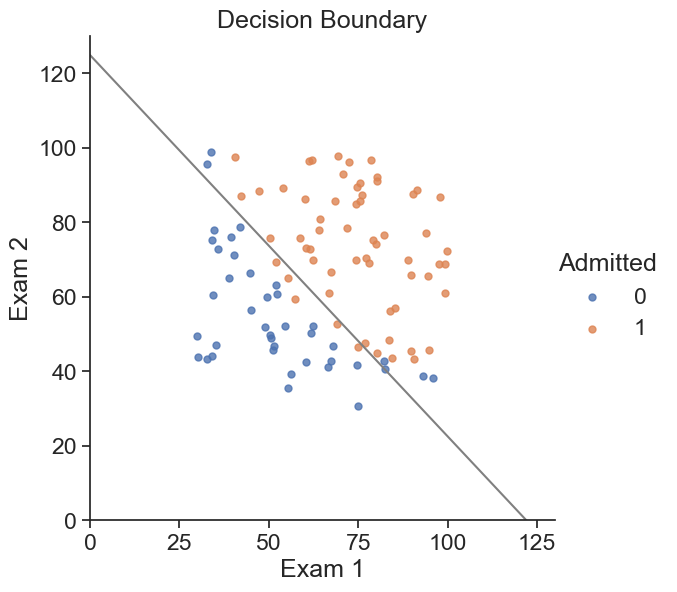

In [107]:
#complete the code below
coef =  theta_min # find the equation

x1 = np.linspace(0, 130, 100)
x2 = -(coef[0] + coef[1] * x1) / coef[2]

sns.set(context="notebook", style="ticks", font_scale=1.5)
data = pd.read_csv('ex2data1.txt', names=['Exam 1', 'Exam 2', 'Admitted']) 
data.columns = ['Exam 1', 'Exam 2', 'Admitted']
sns.lmplot(x='Exam 1', y='Exam 2', hue='Admitted', data=data, 
           height=6, 
           fit_reg=False, 
           scatter_kws={"s": 25}
          )

plt.plot(x1, x2, 'grey')
plt.xlim(0, 130)
plt.ylim(0, 130)
plt.title('Decision Boundary')
plt.show()